### This is an automated workflow for nicely formatting output from ASU's `MERTools:MERspect` software.

Simply modify the variable values in the cell below and then "restart + rerun" the entire kernel. To avoid possible namespace collisions, you should _always_ "restart + rerun" after making a change. It's very fast.

#### Modify the following variable definitions in order to affect what is plotted and how.

The `spectra_fn` variable points to the CSV file containing the spectra.
The format of the spectra can be exactly how it was exported from MERspect, or it can be in the `marslab` format.

You can pass a list of spectra files to plot them all simultaneously, (like `[fn1.csv, fn2.csv]`) but be it might lead to confusing results if they use the same colors, and you will need to redefine `outfile`.

In [15]:
from common.reference import lab_spectra

In [19]:

# If a MERspect formatted file is given, the default is to write a marslab-formatted file with the following tag.
tag = '-marslab'
# Define the output filename --- use `None` to deactivate this behavior.
outfile = spectra_fn.replace(f'{tag}.csv','.csv').replace('.csv',f'{tag}.csv')

The `annotation_string` prints in large characters in the lower left of the plot, rather than a title. You can put anything you want here, but we suggest identifying the sol, camera sequence ID, and target as in the example.

In [20]:
sol = 16
seq_id = 'zcamNNNN'
target_name = 'TargetName'
annotation_string = f'Sol016 : zcamNNNN : TargetName'

If the `solar_elevation` variable is set to a number other than `None`, it will perform the IOF->R* conversion. Only use this if you are sure that the spectra in `spectra_fn` are in units of IOF. (This is the `MERspect` default.) The value to use here can be found as `SOLAR_ELEVATION` in the image headers.

In [21]:
solar_elevation = None#78.3

The `scale_method` variable defines options for scaling the data at the overlapping (800nm) filter. This does not scale errors.
* `"scale_to_left"` - Scale the right eye filters to the left eye filter at 800nm (L1). Merspect default.
* `"scale_to_avg"` - Scale all filters to the average of L1/R1. Marslab default.
* `None` - no scaling

In [4]:
scale_method = "scale_to_avg"
assert(scale_method in ['scale_to_left', 'scale_to_avg', None]) # Tests that the variable has a valid value

The `color_to_feature` dictionary maps `MERspect` colors to a feature name string to be used in the label plot. The syntax should match that of the commented example below. Any colors that don't have a feature defined will be labeled by their color. If defined, the feature will also be written to the `FEATURE` column of the spectra table _if_ you passed a MERspect formatted spectra file; it will not be propagated if you passed a Marslab format file.

In [22]:
                      # Examples---
color_to_feature = {  #'blue' : 'interesting rock',
                      #'green': 'not a creative color',
                      #'red' : 'danger',
                      #'cyan' : 'shadow',
                      #'orange' : 'probably not aliens'
                    }

If this variable is set to a file path, the plot will be saved to that location. The filepath should include a filename that ends with a standard type of image suffix (e.g. `.jpg`, `.png`, `.tiff`).

In [23]:
plot_fn = None#"data/zcam/fakeIOFspectra.jpg"

And some additional parameters for the plot...

In [24]:
# Set the title of the plot
plot_title = 'Fake Spectra'

# This string defines the attribution to be placed in the lower right of the plot
credit = 'Credit:NASA/JPL/ASU/MSSS/Cornell/WWU/MC'

# This parameter defines the background color for the plot.
# Suggested values include 'white', 'whitesmoke', 'lightgray'
bgcolor = 'white'

# Toggle the edges of the plot that are visible as a black line
# Options are 'left','bottom','top','right'
plot_edges = ['left','bottom']
assert(edge in ['left','right','top','bottom'] for edge in plot_edges) # Tests that the variable has a valid value

The `underplot` variable toggles what is underplotted. The options are:
* `None` - Nothing is plotted.
* `"filter"` - The filter transmission profiles are plotted.
* `"grid"` - Gridlines are underplotted.

In [25]:
underplot = "grid"
assert(underplot in [None,'filter','grid']) # Tests that the variable has a valid value

### ----- DO NOT MODIFY ANYTHING BELOW THIS LINE UNLESS YOU ARE SURE -----

In [26]:
# These variables define the width and height of the output plot
# This could mess up the layout in annoying or ugly ways
plot_width = 15
plot_height = 12

In [27]:
%matplotlib inline
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib.font_manager as mplf

import numpy as np

import textwrap
from pathlib import Path

import pandas as pd
pd.options.display.max_columns = None

from marslab.compat.mertools import MERSPECT_COLOR_MAPPINGS, WAVELENGTH_TO_FILTER
from pplot.convert import scale_eyes, merspect_to_marslab, convert_for_plot

import warnings
warnings.filterwarnings('ignore') # Comment this out for testing

from pplot.pplot_utils import *

##### Translate from `MERspect` to `marslab` format if necessary. Save the `marslab`-formatted spectra file.

In [28]:
data = convert_for_plot(spectra_fn,scale_method=scale_method,color_to_feature=color_to_feature)
print('WWU Marslab spectra format:')
display(data)
if outfile:
    print(f"Saving table to {outfile}")
    data.to_csv(outfile,index=None)
data.replace("-", np.nan, inplace=True) # to simplify calculations

KeyError: 'L1'

##### Generate the plot

In [29]:
pretty_plot??

In [32]:
pd.read_csv(lab_spectra['Feldspars']['Maskelynite'])

,Composition,Unnamed: 1
0,Database of Origin,Unknown
1,Date Added,2021-03-20 18:08:52.253899
2,Formula,NaN
3,Grain Size,NaN
4,Locality,NaN
...,...,...
1513,4090.07,0.190766
1514,4092.57,0.190728
1515,4095.07,0.190672
1516,4097.57,0.190579


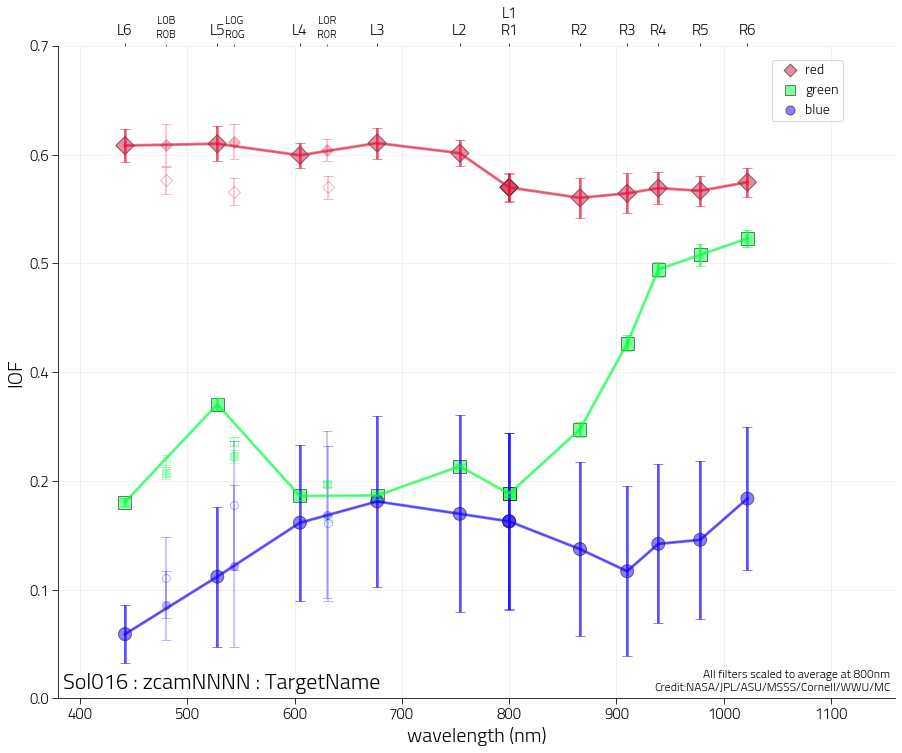

In [30]:
pretty_plot(data,solar_elevation=solar_elevation,
            sym = ['s','o','D','p','^','v','P','X','*','d','H','8','h'],
           sol = sol,seq_id = seq_id,target_name = target_name,
            scale_method=scale_method,
            color_to_feature=color_to_feature,
            plot_fn=plot_fn,
            #plot_title = plot_title,
            credit = credit,
            bgcolor = bgcolor,
            plot_edges = plot_edges,
            underplot = underplot,
            plot_width = plot_width,
            plot_height = plot_height,
           )

The contents of this notebook are provided by the Western Washington University Reflectance Lab (PI: M. Rice) and Million Concepts (C. Million, M. St. Clair) under a BSD 3-Clause License. You may do nearly anything that you want with this code. Questions can be sent to chase@millionconcepts.com

`MERTools`/`MERspect` is proprietary software (Arizona State University) for rover tactical operations made available on an as-needed basis.